## Load libraries

In [1]:
# tensorflow backend
from os import environ
environ['KERAS_BACKEND'] = 'tensorflow'
environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
# vae stuff
from chemvae.vae_utils import VAEUtils
from chemvae import mol_utils as mu
# import scientific py
import numpy as np
import pandas as pd
# rdkit stuff
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import PandasTools
# plotting stuff
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import SVG, display
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

Instructions for updating:
non-resource variables are not supported in the long term


# Load a model

In [2]:
vae = VAEUtils(directory='../models/zinc_properties')

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


From /home/jp2658/.conda/envs/chemvae_tf2/lib/python3.10/site-packages/tensorflow/python/ops/init_ops.py:94: calling GlorotUniform.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


From /home/jp2658/.conda/envs/chemvae_tf2/lib/python3.10/site-packages/tensorflow/python/ops/init_ops.py:94: calling Zeros.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


...

Using standarized functions? True


No training configuration found in the save file, so the model was *not* compiled. Compile it manually.


Standarization: estimating mu and std values ...

/home/jp2658/.conda/envs/chemvae_tf2/lib/python3.10/site-packages/keras/src/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


done!


# Using the VAE


## Decode/Encode 

Might not be perfect (it's probabilistic), try it several times.

smiles <i class="fa fa-arrow-right" aria-hidden="true"></i> x <i class="fa fa-arrow-right" aria-hidden="true"></i> z <i class="fa fa-arrow-right" aria-hidden="true"></i> x_r <i class="fa fa-arrow-right" aria-hidden="true"></i> smiles_r

In [32]:
smiles_1 = mu.canon_smiles('CSCC(=O)NNC(=O)c1c(C)oc(C)c1C')

X_1 = vae.smiles_to_hot(smiles_1,canonize_smiles=True)
z_1 = vae.encode(X_1)
X_r= vae.decode(z_1)

print('{:20s} : {}'.format('Input',smiles_1))
print('{:20s} : {}'.format('Reconstruction',vae.hot_to_smiles(X_r,strip=True)[0]))

print('{:20s} : {} with norm {:.3f}'.format('Z representation',z_1.shape, np.linalg.norm(z_1)))

Input                : CSCC(=O)NNC(=O)c1c(C)oc(C)c1C
Reconstruction       : CSCc(=O)NNC(=O)c1c(C)c(C1)CCO
Z representation     : (1, 196) with norm 10.794


## property preditor

In [33]:
print('Properties (qed,SAS,logP):')
y_1 = vae.predict_prop_Z(z_1)[0]
print(y_1)

Properties (qed,SAS,logP):
[0.76232616 2.31125608 2.09233399]


## Decode several attempts
VAE are probabilistic

Searching molecules randomly sampled from 5.00 std (z-distance) from the point
Found 5 unique mols, out of 5
SMILES
 0    CSC(C(=O)NC(=O)c1c(C)coc1C)CO
1    CSCC(=O)NNC(=O)c1c(C)scc1CC#N
2    CSCC(=O)NNC(=O)c1c(C)coc1CCCO
3    CSCC(=O)NNC(=O)c1cc(C)oc1CC#N
4    CSCC(=O)NNC(=O)c1cc(F)oc1CCCO
Name: smiles, dtype: object


[13:37:52] Can't kekulize mol.  Unkekulized atoms: 9 10 13 15
[13:37:52] Explicit valence for atom # 17 Cl, 3, is greater than permitted
[13:37:52] Can't kekulize mol.  Unkekulized atoms: 9
[13:37:52] Can't kekulize mol.  Unkekulized atoms: 9 10 11 13 14
[13:37:52] Can't kekulize mol.  Unkekulized atoms: 9 10 13
[13:37:52] non-ring atom 3 marked aromatic
[13:37:52] Can't kekulize mol.  Unkekulized atoms: 9 10 13
[13:37:52] non-ring atom 3 marked aromatic
[13:37:52] non-ring atom 9 marked aromatic
[13:37:52] Can't kekulize mol.  Unkekulized atoms: 9 10 13
[13:37:52] Can't kekulize mol.  Unkekulized atoms: 9 10 13
[13:37:52] SMILES Parse Error: ring closure 1 duplicates bond between atom 13 and atom 14 for input: 'CSc1(=O)NNC(=O)c1cc(C)oc1C1C'
[13:37:52] Can't kekulize mol.  Unkekulized atoms: 9 10 13 14 15


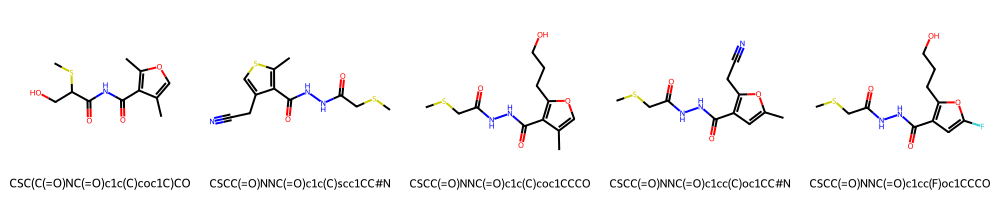

,smiles,distance,count,frequency,mol,z
0,CSC(C(=O)NC(=O)c1c(C)coc1C)CO,6.811445,1,0.2,<rdkit.Chem.rdchem.Mol object at 0x7efbd83f1fc0>,"[[0.09955662895757392, 0.5955984104114829, 1.2..."
1,CSCC(=O)NNC(=O)c1c(C)scc1CC#N,7.026409,1,0.2,<rdkit.Chem.rdchem.Mol object at 0x7efbd83f2180>,"[[0.09955662895757392, 0.5955984104114829, 1.2..."
2,CSCC(=O)NNC(=O)c1c(C)coc1CCCO,7.060113,1,0.2,<rdkit.Chem.rdchem.Mol object at 0x7efdfb2a83c0>,"[[0.09955662895757392, 0.5955984104114829, 1.2..."
3,CSCC(=O)NNC(=O)c1cc(C)oc1CC#N,7.508657,1,0.2,<rdkit.Chem.rdchem.Mol object at 0x7efbd83f20a0>,"[[0.09955662895757392, 0.5955984104114829, 1.2..."
4,CSCC(=O)NNC(=O)c1cc(F)oc1CCCO,8.546825,1,0.2,<rdkit.Chem.rdchem.Mol object at 0x7efbd83f1e00>,"[[0.09955662895757392, 0.5955984104114829, 1.2..."


In [ ]:
noise=5.0
print('Searching molecules randomly sampled from {:.2f} std (z-distance) from the point'.format(noise))
df = vae.z_to_smiles(z_1,decode_attempts=100,noise_norm=noise)
print('Found {:d} unique mols, out of {:d}'.format(len(set(df['smiles'])),sum(df['count'])))
print('SMILES\n',df.smiles)
display(PandasTools.FrameToGridImage(df,column='mol', legendsCol='smiles',molsPerRow=5))
df.head()

## PCA of latent space

Sample random points from the training set along with properties

In [6]:
Z, data, smiles = vae.ls_sampler_w_prop(size=50000,return_smiles=True)
prop_opt = 'qed'
prop_df = pd.DataFrame(data).reset_index()
prop_df['smiles']=smiles
prop_df.head()

,index,logP,qed,SAS,smiles
0,183390,2.0002,0.666126,2.074465,COc1cc(C(=O)N2CCN(S(=O)(=O)Cc3ccccc3)CC2)cc(OC...
1,89039,1.7129,0.581648,3.003569,[O-]c1nc(SCCc2ccccc2)c2ncnc-2[nH]1
2,87084,2.2121,0.908477,2.780384,O=C(CCOC1CCOCC1)N[C@@H]1CCOc2ccccc21
3,233837,1.8613,0.573491,2.969187,C=CN1CC[C@H](C(=O)c2ccccc2)C1=O
4,201708,2.9071,0.867405,2.673845,COCCn1cc(NC(=O)N2CCC[C@H]2c2cccc(OC)c2)cn1


Perform a PCA projection and color the points based on a property

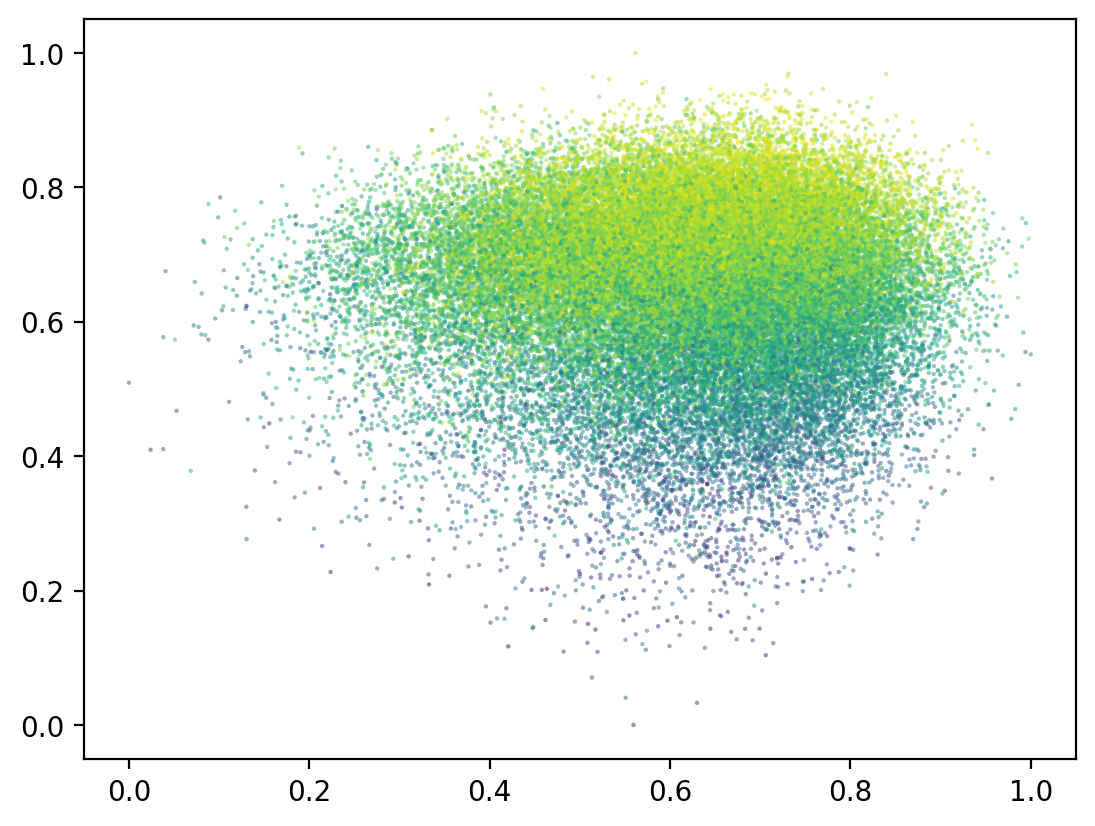

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# do pca and normalize
Z_pca = PCA(n_components=2).fit_transform(Z)
Z_pca = MinMaxScaler().fit_transform(Z_pca)

df = pd.DataFrame(np.transpose((Z_pca[:,0],Z_pca[:,1])))
df.columns = ['x','y']
df[prop_opt]=prop_df[prop_opt]

plt.scatter(x=df['x'], y=df['y'], c=df[prop_opt],
            cmap= 'viridis', marker='.',
            s=10,alpha=0.5, edgecolors='none')
plt.show()

compare with t-SNE, will take some time

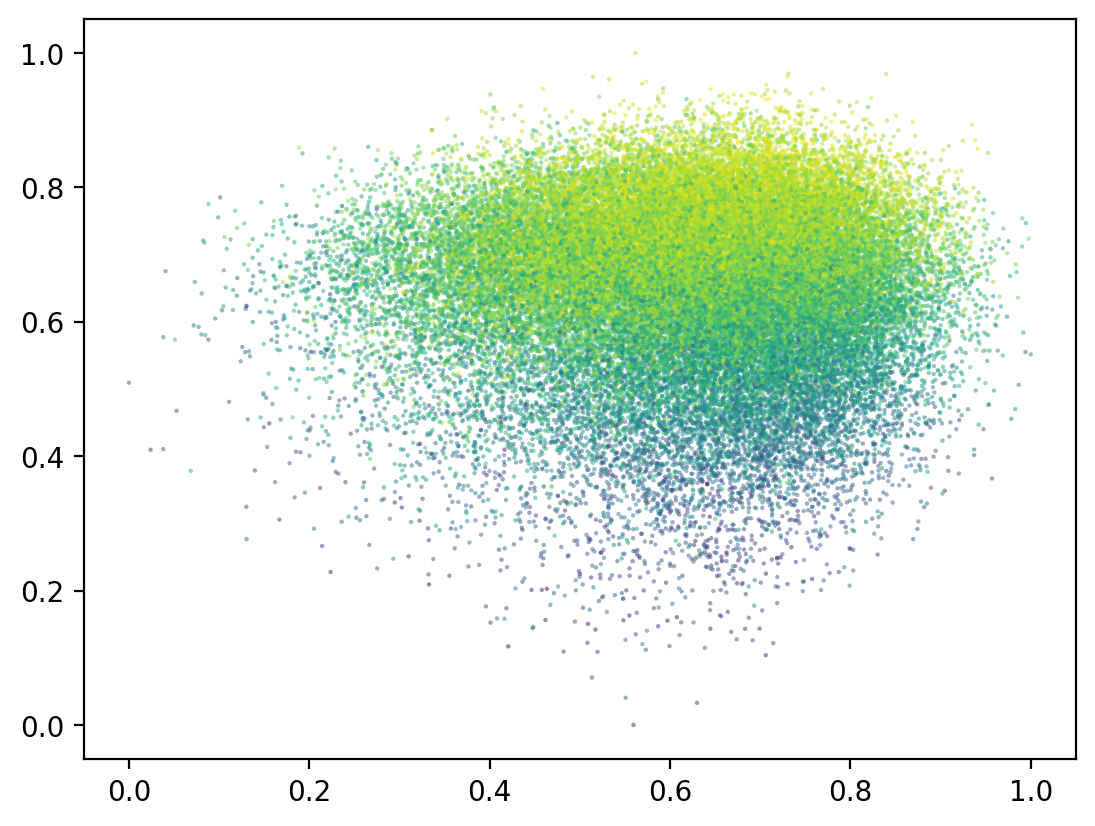

In [8]:
from sklearn.manifold import TSNE

Z_tsne = TSNE(n_components=2).fit_transform(Z)
Z_tsne = MinMaxScaler().fit_transform(Z_tsne)

f = pd.DataFrame(np.transpose((Z_tsne[:,0],Z_tsne[:,1])))
df.columns = ['x','y',prop_opt]
df[prop_opt]=prop_df[prop_opt]

plt.scatter(x=df['x'], y=df['y'], c=df[prop_opt],
            cmap= 'viridis', marker='.',
            s=10,alpha=0.5, edgecolors='none')
plt.show()